In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('../data/processed/ga4_merch_store_clean.csv')
print(df.shape)
df.head()

(85598, 11)


,user_pseudo_id,event_date,traffic_medium,traffic_source,device_category,session_count,items_viewed,add_to_cart_count,checkout_started,purchases,converted
0,1.005695e+06,2020-11-01,organic,google,desktop,1,0,0,0,0,0
1,1.013443e+06,2020-11-01,(none),(direct),mobile,1,1,0,0,0,0
2,1.019517e+06,2020-11-01,referral,<Other>,desktop,1,0,0,0,0,0
3,1.019517e+06,2020-11-01,(none),(direct),desktop,1,0,0,0,0,0
4,1.055429e+06,2020-11-01,<Other>,<Other>,desktop,1,0,0,0,0,0


In [2]:
# Features für Clustering auswählen
features = ['session_count', 'items_viewed', 'add_to_cart_count', 'checkout_started', 'purchases']

X = df[features].copy()

# Skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Matrix Shape:", X_scaled.shape)


Feature Matrix Shape: (85598, 5)


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\s-web\miniconda3\envs\eda-merch\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\s-web\miniconda3\envs\eda-merch\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\s-web\miniconda3\envs\eda-merch\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 109: invalid start byte


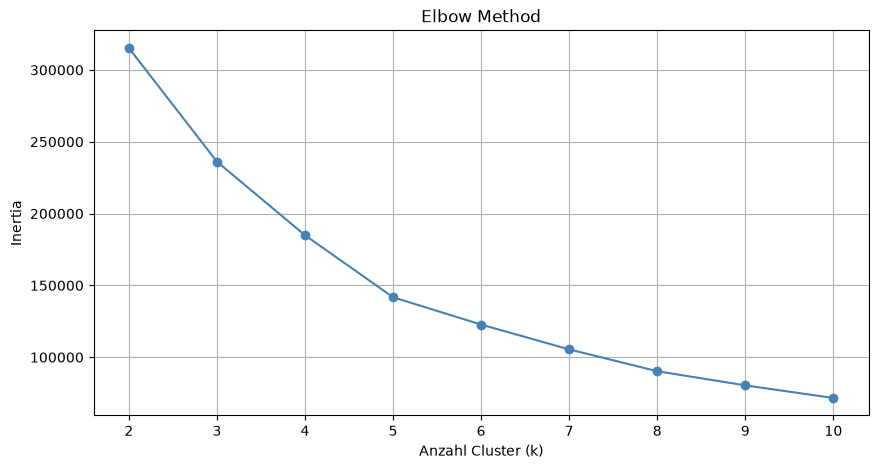

In [3]:
# Elbow Method
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [4]:
# Silhouette Scores
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)
    print(f"k={k}: {score:.4f}")

k=2: 0.9198
k=3: 0.9264
k=4: 0.9326
k=5: 0.9343
k=6: 0.9350
k=7: 0.9366
k=8: 0.9371
k=9: 0.9328
k=10: 0.9118


In [5]:
# Finales Clustering mit k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Größen
print("Cluster Größen:")
print(df['cluster'].value_counts().sort_index())

Cluster Größen:
cluster
0    81377
1     2110
2      885
3     1226
Name: count, dtype: int64


In [6]:
# Log-Transformation
X_log = df[features].copy()
X_log = np.log1p(X_log)  # log1p weil log(0) undefined

scaler = StandardScaler()
X_scaled_log = scaler.fit_transform(X_log)

# Finales Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled_log)

print("Cluster Größen:")
print(df['cluster'].value_counts().sort_index())

Cluster Größen:
cluster
0    79610
1     2790
2     1114
3     2084
Name: count, dtype: int64


In [7]:
# Nur aktive User: mindestens 1 item_viewed
df_active = df[df['items_viewed'] > 0].copy()
print(f"Aktive User: {len(df_active)} von {len(df)} ({len(df_active)/len(df):.1%})")

# Features neu skalieren
X_active = df_active[features].copy()
X_active_log = np.log1p(X_active)
X_active_scaled = scaler.fit_transform(X_active_log)

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_active['cluster'] = kmeans.fit_predict(X_active_scaled)

print("\nCluster Größen:")
print(df_active['cluster'].value_counts().sort_index())

Aktive User: 20793 von 85598 (24.3%)

Cluster Größen:
cluster
0    16813
1     2088
2     1057
3      835
Name: count, dtype: int64


In [8]:
# Cluster Profil
print(df_active.groupby('cluster')[features].mean().round(2))


         session_count  items_viewed  add_to_cart_count  checkout_started  \
cluster                                                                     
0                 1.00          2.84               0.02              0.04   
1                 1.00         26.12               0.88              1.45   
2                 1.03         12.08               0.79              2.66   
3                 2.07          5.57               0.08              0.29   

         purchases  
cluster             
0             0.00  
1             0.00  
2             1.32  
3             0.04  


In [9]:
# Conversion Rate pro Cluster
print("Conversion Rate pro Cluster:")
print(df_active.groupby('cluster')['converted'].mean().mul(100).round(2))

Conversion Rate pro Cluster:
cluster
0      0.00
1      0.00
2    100.00
3      4.07
Name: converted, dtype: float64
